# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')  #hiding warning messages

In [3]:
df = pd.read_csv('data/Synthetic_Financial_datasets_log.csv') #file im working on.

In [4]:
df.head()  #I wanted to see small sample of file to know how it looks like

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()    #checking on data types

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [7]:
df["isFraud"].value_counts()   #counting how many frauds are in file

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:

df.isnull().sum()   #checking if there are any missing values in data set.

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

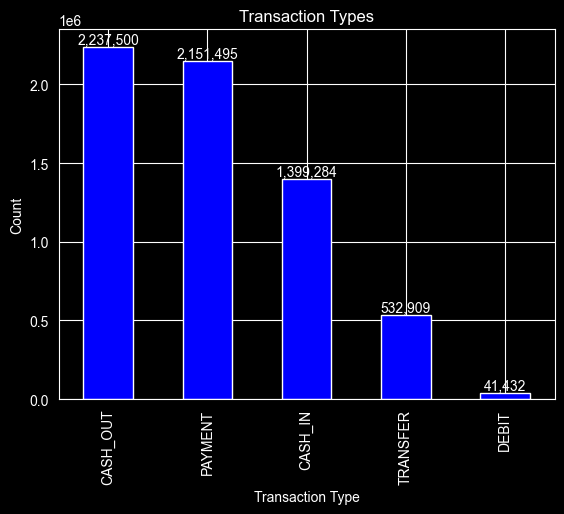

In [9]:
ax = df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="blue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")  #creating a bar that shows how many different transactions there are
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom') #adding numbers on top of the bar
plt.show()

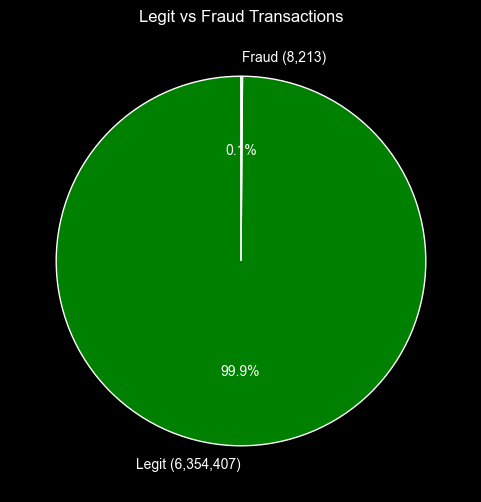

In [10]:
colors = ["green", "red"]
counts = df["isFraud"].value_counts()
labels = [f"Legit ({counts[0]:,})", f"Fraud ({counts[1]:,})"]
plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Legit vs Fraud Transactions")
plt.show()     #creating pie chart showing legit vs fraud transaction count.

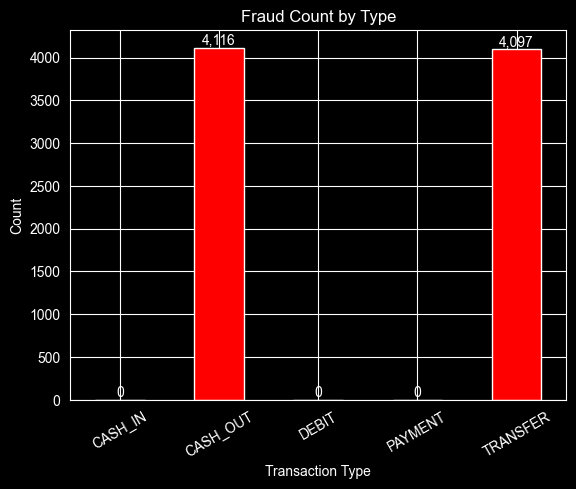

In [11]:
ax = df.groupby("type")["isFraud"].sum().plot(kind="bar", title="Fraud Count by Type", color="red")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=30) #transactions type are tilted at 30 degrees so they not overlap with each other.
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom') #again adding number on top of bar
plt.show()

In [12]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

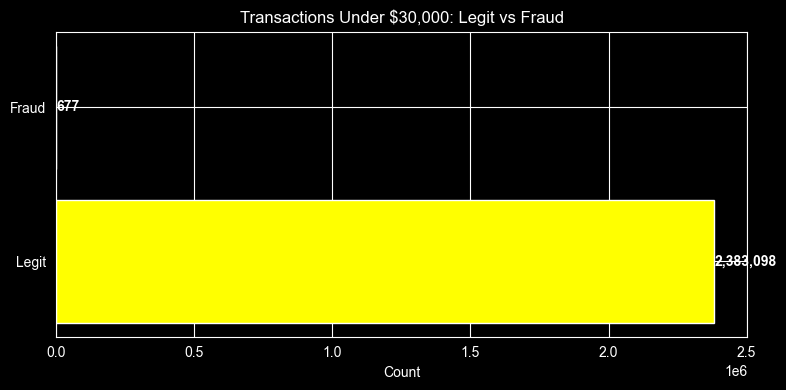

In [13]:
#Filter transactions under 30k
under_30k = df[df['amount'] < 30000]
counts = [
    len(under_30k[under_30k['isFraud']==0]),
    len(under_30k[under_30k['isFraud']==1])]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['Legit', 'Fraud'], counts, color=['Yellow', 'Purple'])
plt.title('Transactions Under $30,000: Legit vs Fraud')
plt.xlabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

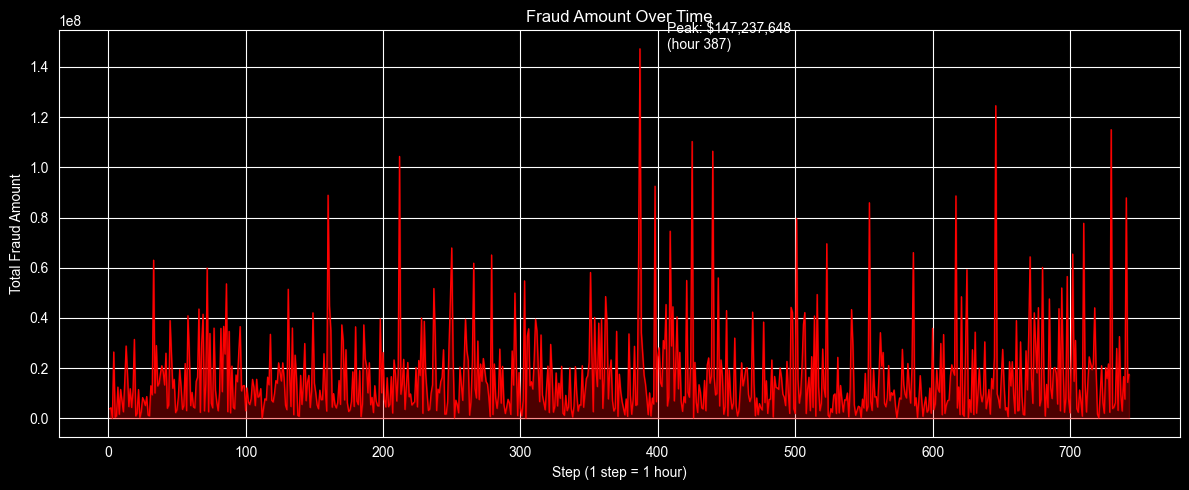

In [14]:
fraud_over_time = df[df['isFraud']==1].groupby('step')['amount'].sum()  #suming only fraud transactions.
plt.figure(figsize=(12, 5))
plt.plot(fraud_over_time, color='red', linewidth=1)
plt.fill_between(fraud_over_time.index, fraud_over_time, color='red', alpha=0.3)  #filling area under the line whit red.
peak_step = fraud_over_time.idxmax() #hour with most fraud
peak_value = fraud_over_time.max() #finding peak value
plt.annotate(f'Peak: ${peak_value:,.0f}\n(hour {peak_step})',
             xy=(peak_step, peak_value),
             xytext=(peak_step + 20, peak_value)) #showing peak
plt.title('Fraud Amount Over Time')
plt.xlabel('Step (1 step = 1 hour)')
plt.ylabel('Total Fraud Amount')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [16]:
df_ml = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud', 'step'], axis=1)  #remove unnecessary columns

In [17]:
df_ml.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [18]:
fraud = df[df['isFraud'] == 1] #filters fraud
legit = df[df['isFraud'] == 0].sample(n=len(fraud), random_state=42) #filters legit, picking same number of rows as fraud.
balanced = pd.concat([fraud, legit]).sample(frac=1, random_state=42) #combining fraud and legit, but they are not grouped togheter.
X = balanced[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]  #model learns from it
y = balanced['isFraud'] #answers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  #spliting data 80/20 %

In [19]:
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
categorical_cols = ['type']   #separating data types, numbers from text.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(), categorical_cols)])   #preparing raw data so the model can understand it.

In [20]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))])  #runing everything together (preprocessor and model)

In [21]:
pipeline.fit(X_train, y_train)   #training

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [22]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred,target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       0.90      0.93      0.91      1622
       Fraud       0.93      0.89      0.91      1664

    accuracy                           0.91      3286
   macro avg       0.91      0.91      0.91      3286
weighted avg       0.91      0.91      0.91      3286



In [23]:
confusion_matrix(y_test, y_pred)

array([[1507,  115],
       [ 175, 1489]])

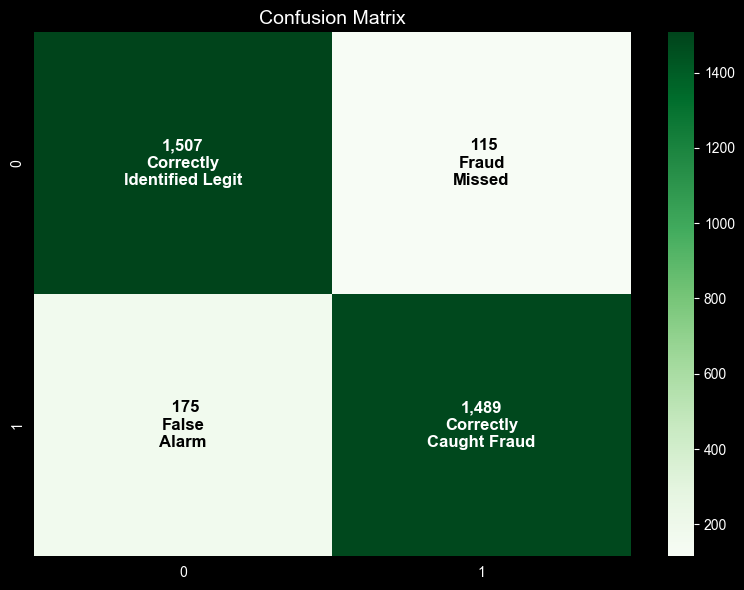

In [24]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens')
plt.text(0.5, 0.5, f'{cm[0,0]:,}\nCorrectly\nIdentified Legit',ha='center',va='center',fontsize=12,color='white',fontweight='bold')
plt.text(1.5, 0.5, f' {cm[0,1]:,}\nFraud\nMissed',ha='center', va='center',fontsize=12,color='black',fontweight='bold')
plt.text(0.5, 1.5, f' {cm[1,0]:,}\nFalse\nAlarm',ha='center', va='center',fontsize=12,color='black',fontweight='bold')
plt.text(1.5, 1.5, f'{cm[1,1]:,}\nCorrectly\nCaught Fraud',ha='center', va='center', fontsize=12, color='white',fontweight='bold')
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()
#creating matrix to show how many correct and incorrect predictions model made.

In [25]:
pipeline.score(X_test, y_test) * 100

91.17468046256847

In [26]:
import joblib
joblib.dump(pipeline,"fraud_pipeline.pkl")

['fraud_pipeline.pkl']